In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Plot style
plt.style.use('ggplot')

In [2]:
df = pd.read_csv('ipl_2026_cleaned.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (17477, 25)


,match_id,season,phase,match_no,date,venue,batting_team,bowling_team,innings,over,striker,bowler,runs_of_bat,extras,wide,legbyes,byes,noballs,wicket_type,player_dismissed,fielder,year,month,day,total_runs
0,202601,2026,Group Stage,1,2026-03-28,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.1,Travis Head,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN,2026,March,Saturday,0
1,202601,2026,Group Stage,1,2026-03-28,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.2,Travis Head,Jacob Duffy,1,0,0,0,0,0,NaN,NaN,NaN,2026,March,Saturday,1
2,202601,2026,Group Stage,1,2026-03-28,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.3,Abhishek Sharma,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN,2026,March,Saturday,0
3,202601,2026,Group Stage,1,2026-03-28,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.4,Abhishek Sharma,Jacob Duffy,6,0,0,0,0,0,NaN,NaN,NaN,2026,March,Saturday,6
4,202601,2026,Group Stage,1,2026-03-28,"M.Chinnaswamy Stadium, Bengaluru",SRH,RCB,1,0.5,Abhishek Sharma,Jacob Duffy,0,0,0,0,0,0,NaN,NaN,NaN,2026,March,Saturday,0


In [3]:
print("Columns in Dataset:\n")
print(df.columns)

print("\nDataset Info:\n")
df.info()

Columns in Dataset:

Index(['match_id', 'season', 'phase', 'match_no', 'date', 'venue',
       'batting_team', 'bowling_team', 'innings', 'over', 'striker', 'bowler',
       'runs_of_bat', 'extras', 'wide', 'legbyes', 'byes', 'noballs',
       'wicket_type', 'player_dismissed', 'fielder', 'year', 'month', 'day',
       'total_runs'],
      dtype='object')

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17477 entries, 0 to 17476
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   match_id          17477 non-null  int64  
 1   season            17477 non-null  int64  
 2   phase             17477 non-null  object 
 3   match_no          17477 non-null  int64  
 4   date              17477 non-null  object 
 5   venue             17477 non-null  object 
 6   batting_team      17477 non-null  object 
 7   bowling_team      17477 non-null  object 
 8   innings           17477 non-null  int64  


In [4]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

print(missing_values)

wicket_type         16598
player_dismissed    16602
fielder             16791
dtype: int64


In [5]:
numerical_cols = df.select_dtypes(include=['int64','float64'])

summary_stats = numerical_cols.describe().T

summary_stats['Median'] = numerical_cols.median()

summary_stats

,count,mean,std,min,25%,50%,75%,max,Median
match_id,17477.0,202637.987927,21.299799,202601.0,202620.0,202638.0,202657.0,202674.0,202638.0
season,17477.0,2026.000000,0.000000,2026.0,2026.0,2026.0,2026.0,2026.0,2026.0
match_no,17477.0,37.987927,21.299799,1.0,20.0,38.0,57.0,74.0,38.0
innings,17477.0,1.480002,0.500301,1.0,1.0,1.0,2.0,4.0,1.0
over,17477.0,9.478646,5.649094,0.1,4.5,9.4,14.3,19.6,9.4
runs_of_bat,17477.0,1.496424,1.852155,0.0,0.0,1.0,2.0,6.0,1.0
extras,17477.0,0.071122,0.336309,0.0,0.0,0.0,0.0,5.0,0.0
wide,17477.0,0.042627,0.202022,0.0,0.0,0.0,0.0,1.0,0.0
legbyes,17477.0,0.010185,0.100407,0.0,0.0,0.0,0.0,1.0,0.0
byes,17477.0,0.002403,0.048964,0.0,0.0,0.0,0.0,1.0,0.0


In [6]:
summary_stats.to_csv("numerical_summary_statistics.csv")

print("Summary statistics saved successfully.")

Summary statistics saved successfully.


In [7]:
categorical_cols = df.select_dtypes(include=['object'])

for col in categorical_cols.columns:
    print("\n" + "="*50)
    print("Column:", col)
    print(df[col].value_counts().head(10))


Column: phase
phase
Group Stage    16502
Eliminator       252
Qualifier 1      250
Qualifier 2      241
Final            232
Name: count, dtype: int64

Column: date
date
2026-04-18    507
2026-04-19    506
2026-05-17    502
2026-05-10    502
2026-04-11    499
2026-04-12    498
2026-04-25    497
2026-05-24    494
2026-04-04    490
2026-04-05    490
Name: count, dtype: int64

Column: venue
venue
Narendra Modi Stadium, Ahmedabad                                                      1851
Rajiv Gandhi International Stadium, Hyderabad                                         1745
Wankhede Stadium, Mumbai                                                              1727
MA Chidambaram Stadium, Chennai                                                       1713
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow                 1663
Arun Jaitley Stadium, Delhi                                                           1569
Eden Gardens, Kolkata                                   

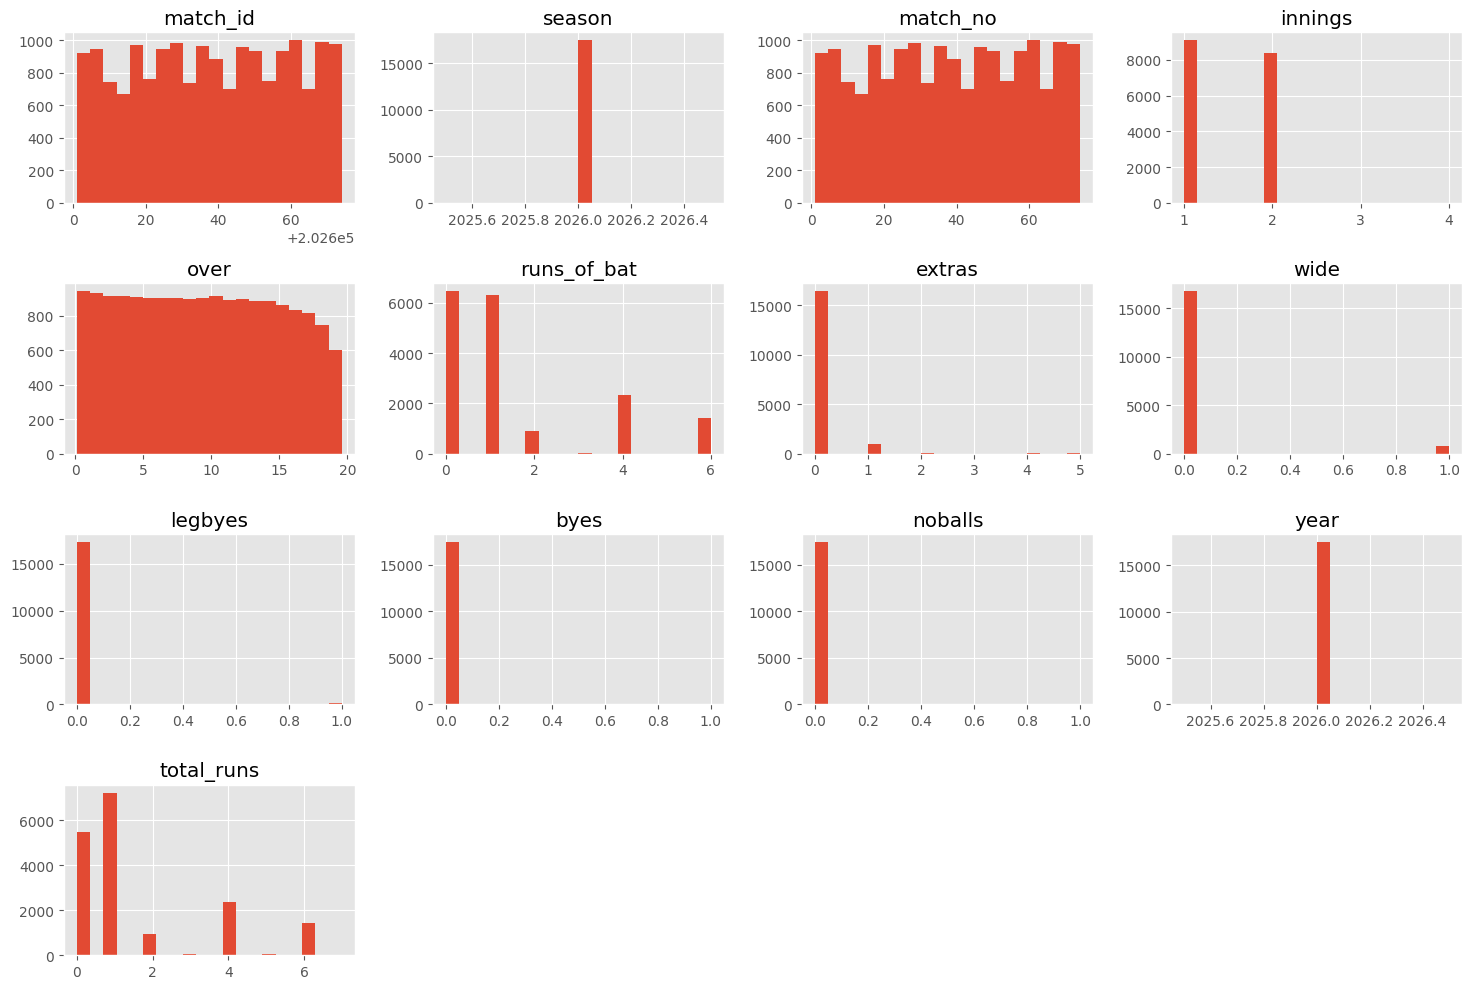

In [8]:
numerical_cols.hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

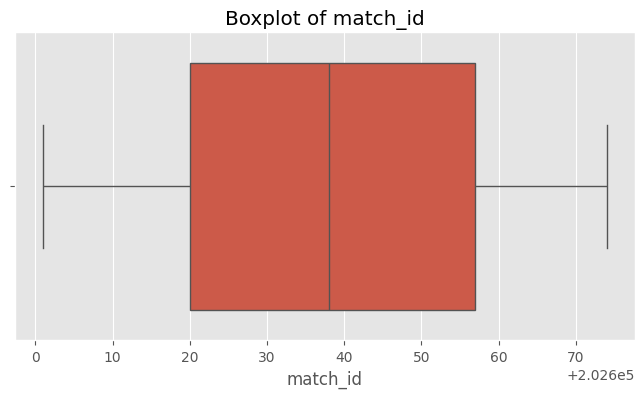

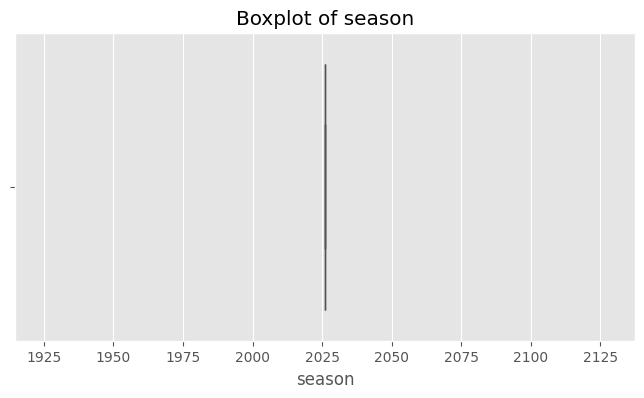

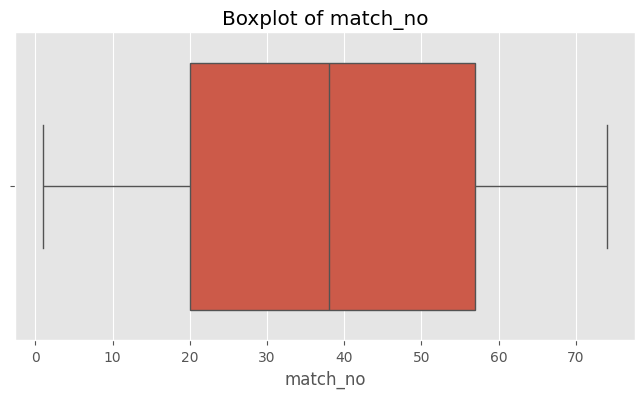

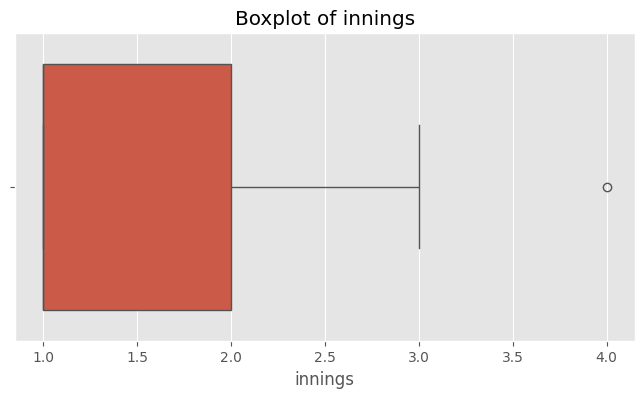

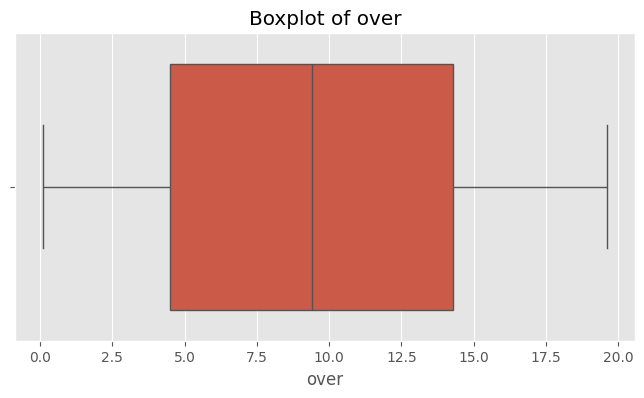

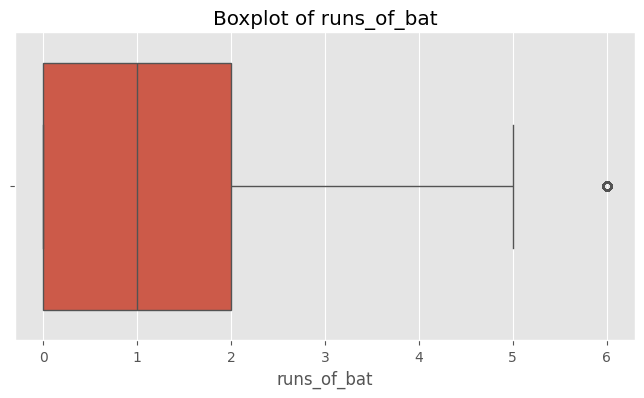

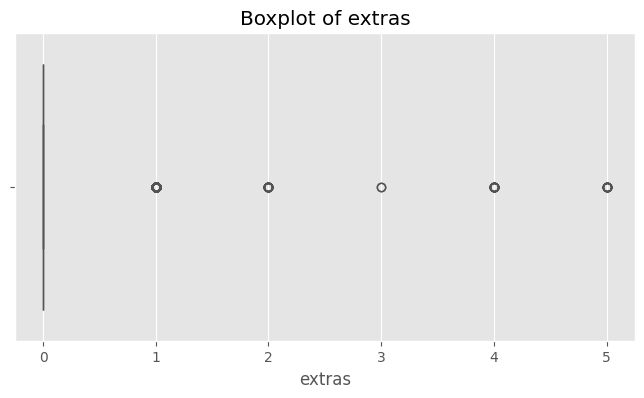

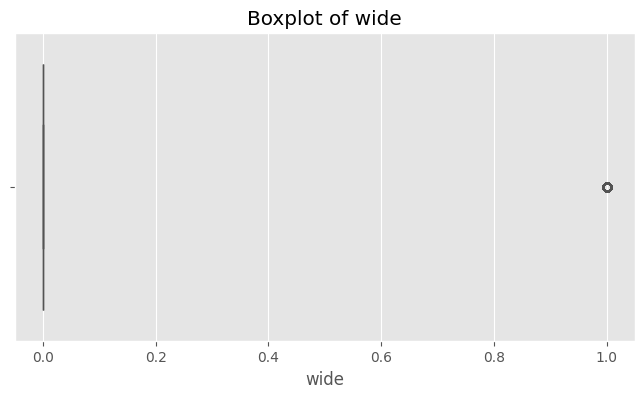

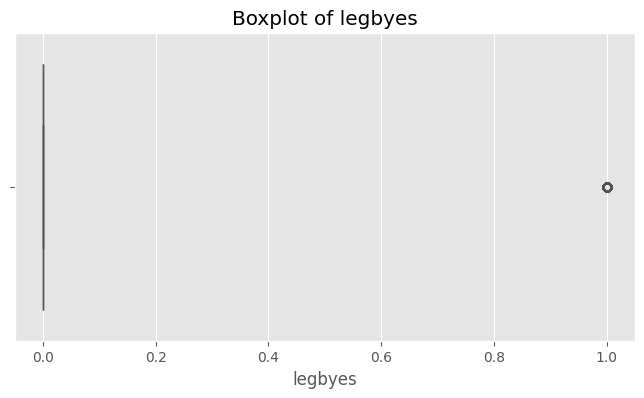

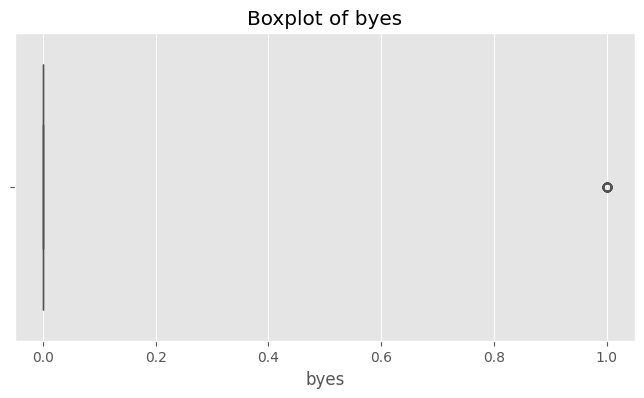

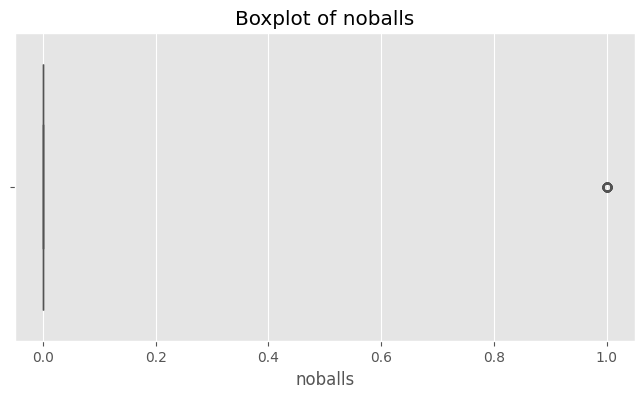

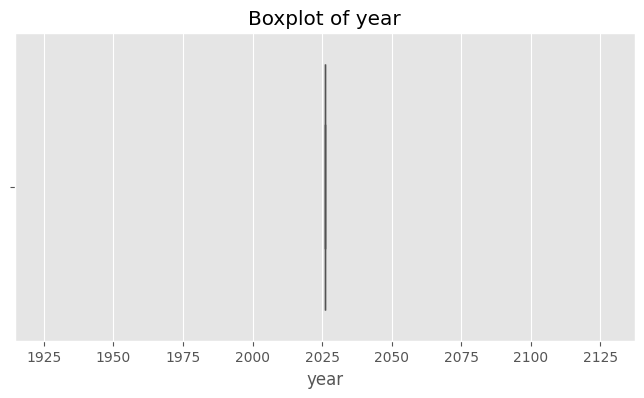

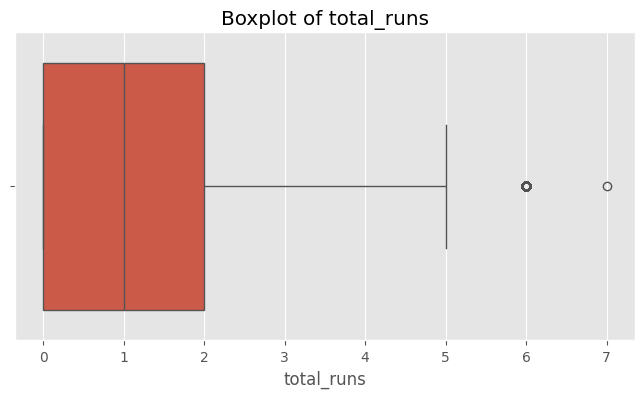

In [9]:
for col in numerical_cols.columns:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

In [10]:
categorical_cols = df.select_dtypes(include=['object'])

print(categorical_cols.columns)

Index(['phase', 'date', 'venue', 'batting_team', 'bowling_team', 'striker',
       'bowler', 'wicket_type', 'player_dismissed', 'fielder', 'month', 'day'],
      dtype='object')


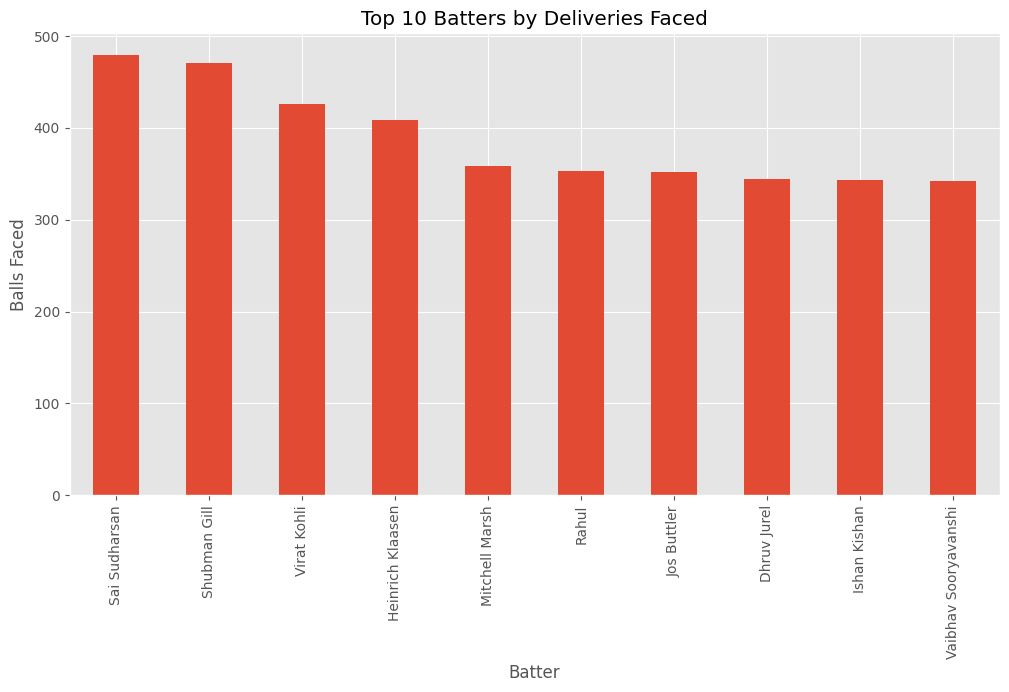

In [13]:
plt.figure(figsize=(12,6))

df['striker'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Batters by Deliveries Faced')

plt.xlabel('Batter')

plt.ylabel('Balls Faced')

plt.show()

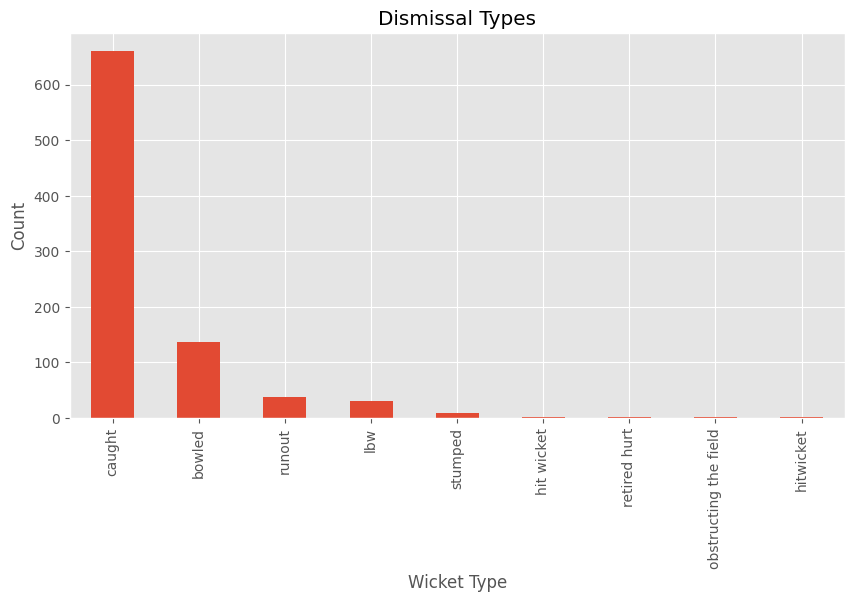

In [15]:
plt.figure(figsize=(10,5))

df['wicket_type'].value_counts().plot(kind='bar')

plt.title('Dismissal Types')

plt.xlabel('Wicket Type')

plt.ylabel('Count')

plt.show()

In [16]:
print(df.columns.tolist())

['match_id', 'season', 'phase', 'match_no', 'date', 'venue', 'batting_team', 'bowling_team', 'innings', 'over', 'striker', 'bowler', 'runs_of_bat', 'extras', 'wide', 'legbyes', 'byes', 'noballs', 'wicket_type', 'player_dismissed', 'fielder', 'year', 'month', 'day', 'total_runs']


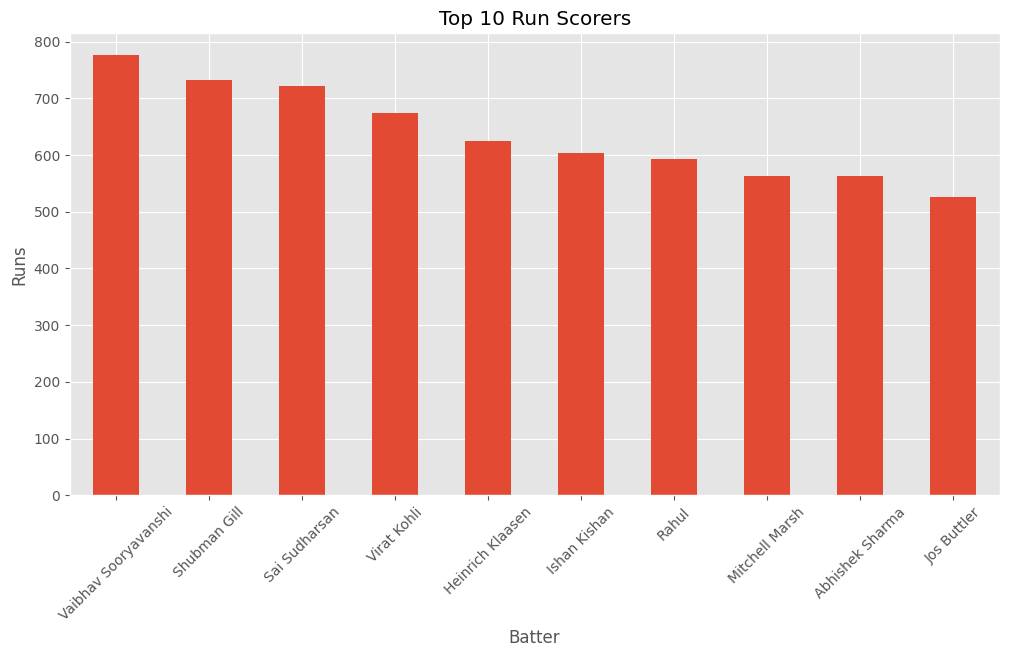

In [17]:
batter_runs = df.groupby('striker')['runs_of_bat'].sum()

top_batters = batter_runs.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

top_batters.plot(kind='bar')

plt.title('Top 10 Run Scorers')

plt.xlabel('Batter')

plt.ylabel('Runs')

plt.xticks(rotation=45)

plt.show()

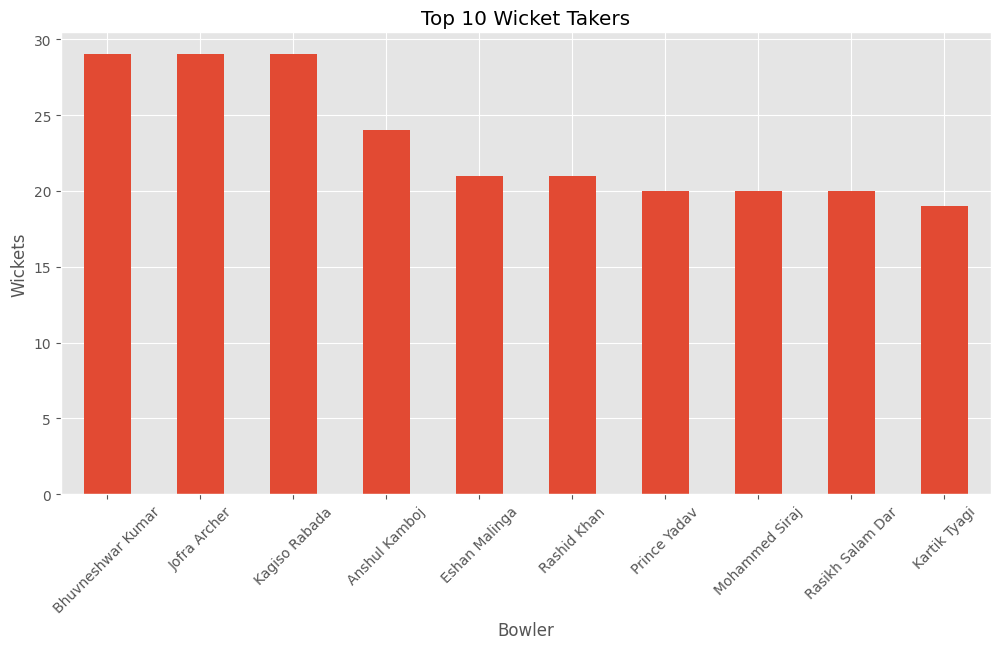

In [18]:
wickets = df[df['player_dismissed'].notna()]

top_bowlers = wickets.groupby('bowler').size()

top_bowlers = top_bowlers.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,6))
top_bowlers.plot(kind='bar')

plt.title('Top 10 Wicket Takers')
plt.xlabel('Bowler')
plt.ylabel('Wickets')
plt.xticks(rotation=45)

plt.show()

In [31]:
#SQL
import sqlite3
conn = sqlite3.connect("ipl.db")
df.to_sql("ipl", conn, if_exists="replace", index=False)


17477

In [32]:
query = """
SELECT striker,
       SUM(runs_of_bat) AS total_runs
FROM ipl
GROUP BY striker
ORDER BY total_runs DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)

result

,striker,total_runs
0,Vaibhav Sooryavanshi,776
1,Shubman Gill,732
2,Sai Sudharsan,722
3,Virat Kohli,675
4,Heinrich Klaasen,624
5,Ishan Kishan,604
6,Rahul,593
7,Mitchell Marsh,563
8,Abhishek Sharma,563
9,Jos Buttler,526


In [35]:
query = """
SELECT bowler,
       COUNT(player_dismissed) AS wickets
FROM ipl
WHERE player_dismissed IS NOT NULL
GROUP BY bowler
ORDER BY wickets DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)

result

,bowler,wickets
0,Kagiso Rabada,29
1,Jofra Archer,29
2,Bhuvneshwar Kumar,29
3,Anshul Kamboj,24
4,Rashid Khan,21
5,Eshan Malinga,21
6,Rasikh Salam Dar,20
7,Prince Yadav,20
8,Mohammed Siraj,20
9,Kartik Tyagi,19


In [34]:
query = """
SELECT striker,
       SUM(runs_of_bat) AS total_runs
FROM ipl
GROUP BY striker
ORDER BY total_runs DESC
LIMIT 10;
"""

result = pd.read_sql(query, conn)

result


,batting_team,team_runs
0,GT,3083
1,RR,3071
2,RCB,3054
3,SRH,3041
4,PBKS,2704
5,MI,2552
6,DC,2552
7,CSK,2523
8,LSG,2505
9,KKR,2311


In [36]:
query = """
SELECT wicket_type,
       COUNT(*) AS dismissals
FROM ipl
WHERE wicket_type IS NOT NULL
GROUP BY wicket_type
ORDER BY dismissals DESC;
"""

result = pd.read_sql(query, conn)

result

,wicket_type,dismissals
0,caught,660
1,bowled,137
2,runout,38
3,lbw,30
4,stumped,9
5,hit wicket,2
6,retired hurt,1
7,obstructing the field,1
8,hitwicket,1


In [23]:
# Multivarient analysis



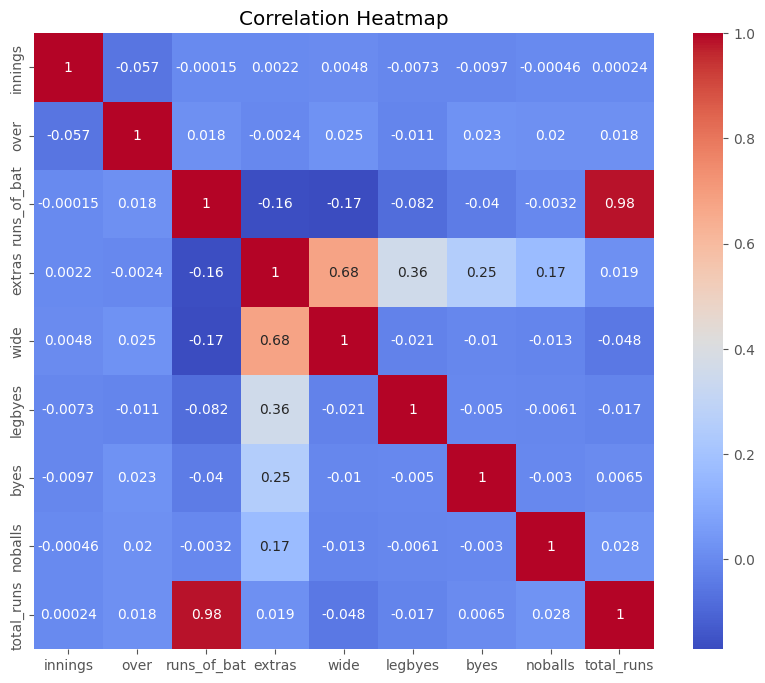

In [21]:
numeric_cols = [
    'innings',
    'over',
    'runs_of_bat',
    'extras',
    'wide',
    'legbyes',
    'byes',
    'noballs',
    'total_runs'
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

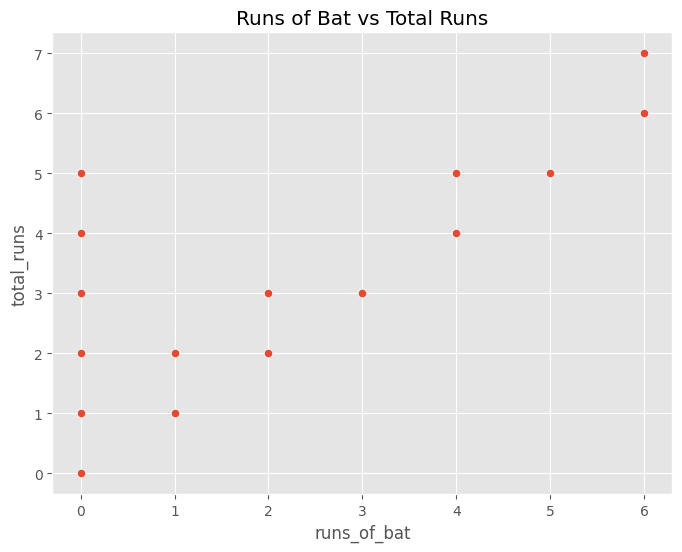

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='runs_of_bat',
    y='total_runs'
)

plt.title('Runs of Bat vs Total Runs')

plt.show()

In [37]:
print("Total Matches:", df['match_id'].nunique())
print("Total Runs:", df['total_runs'].sum())
print("Total Wickets:", df['player_dismissed'].notna().sum())
print("Total Batters:", df['striker'].nunique())
print("Total Bowlers:", df['bowler'].nunique())

Total Matches: 74
Total Runs: 27396
Total Wickets: 875
Total Batters: 177
Total Bowlers: 127
